In [ ]:
!pip install dtreeviz

In [ ]:
import graphviz.backend as be

from sklearn.datasets import *
from dtreeviz import model
from IPython.display import Image, display_svg, SVG

In [ ]:
from sklearn import tree
clas = tree.DecisionTreeClassifier()
iris = load_iris()

X_train = iris.data
y_train = iris.target
clas.fit(X_train, y_train)

DecisionTreeClassifier()

[Text(0.5, 0.9166666666666666, 'x[2] <= 2.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.4230769230769231, 0.75, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.46153846153846156, 0.8333333333333333, 'True  '),
 Text(0.5769230769230769, 0.75, 'x[3] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5384615384615384, 0.8333333333333333, '  False'),
 Text(0.3076923076923077, 0.5833333333333334, 'x[2] <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.15384615384615385, 0.4166666666666667, 'x[3] <= 1.65\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.07692307692307693, 0.25, 'gini = 0.0\nsamples = 47\nvalue = [0, 47, 0]'),
 Text(0.23076923076923078, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.46153846153846156, 0.4166666666666667, 'x[3] <= 1.55\ngini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.38461538461538464, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.5384615384615384, 0.25, 

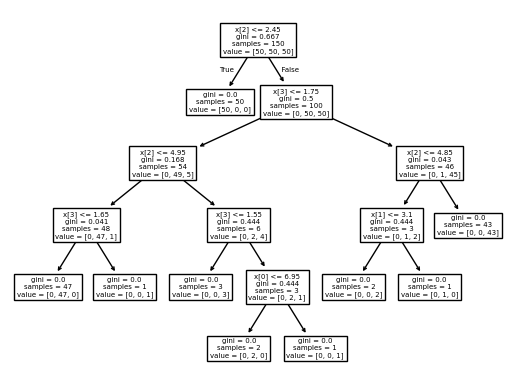

In [ ]:
from sklearn.tree import plot_tree
plot_tree(clas)


1. Classification

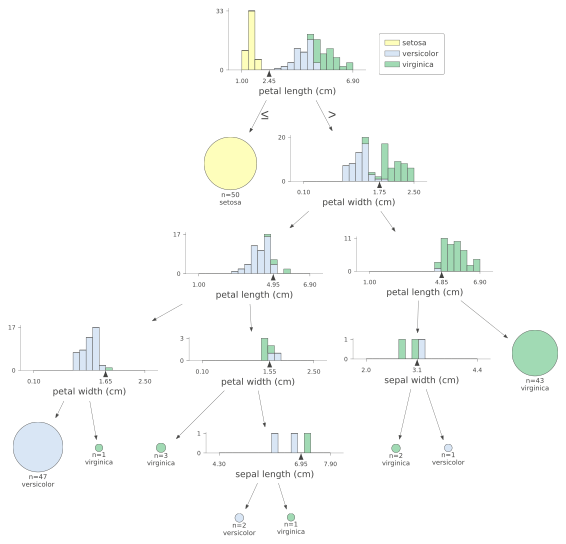

In [ ]:
m = model(clas,
          X_train=X_train,
          y_train=y_train,
          feature_names=iris.feature_names,
          class_names=iris.target_names)
viz = m.view()
viz

3. Horizontal Decision Tree


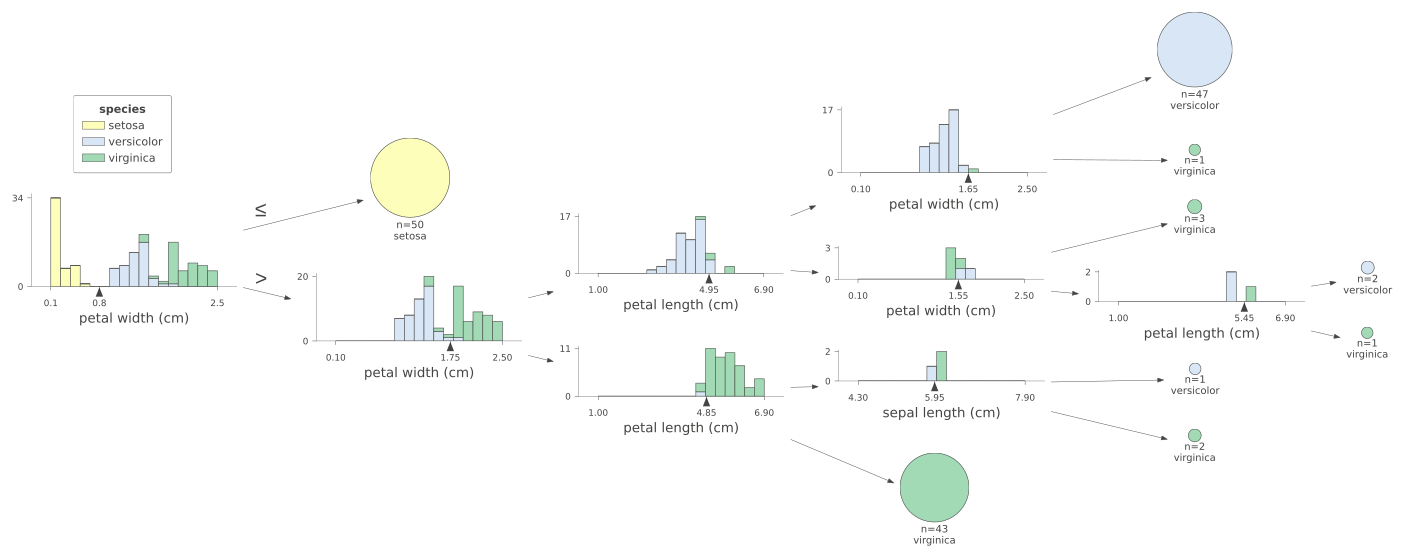

In [ ]:
m = model(clas,
          X_train=X_train,
          y_train=y_train,
          feature_names=iris.feature_names,
          target_name='species', # Changed from 'price' for Iris dataset
          class_names=iris.target_names) # Using iris.target_names
viz = m.view(scale=1.5,
             orientation='LR')
viz

4. Show Prediction Path

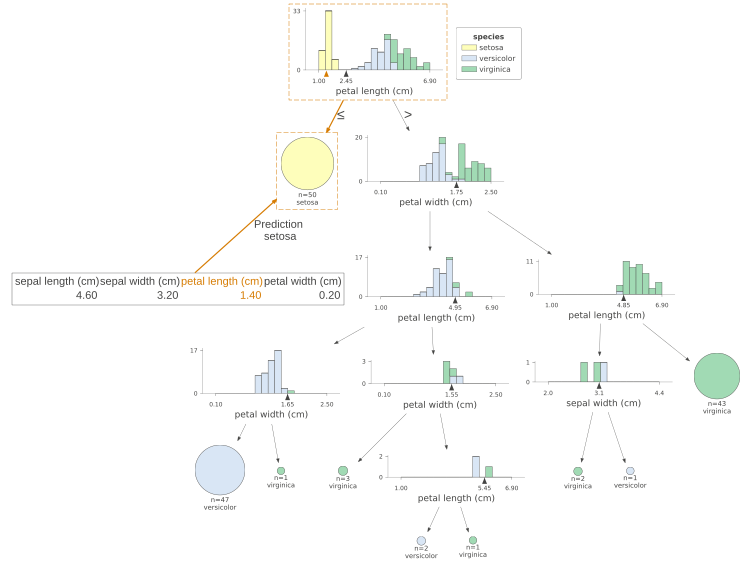

In [ ]:
import numpy as np
from sklearn import tree
from sklearn.datasets import load_iris
from dtreeviz import model # Ensure model is imported

clas = tree.DecisionTreeClassifier()
iris = load_iris()

X_train = iris.data
y_train = iris.target
clas.fit(X_train, y_train)

X = iris.data[np.random.randint(0, len(iris.data)),:]

m = model(clas,
          X_train=X_train,
          y_train=y_train,
          feature_names=iris.feature_names,
          target_name='species', # Added target_name for Iris dataset
          class_names=iris.target_names)
viz = m.view(x=X) # X is now passed as 'x' to view()
viz

5. Show node number

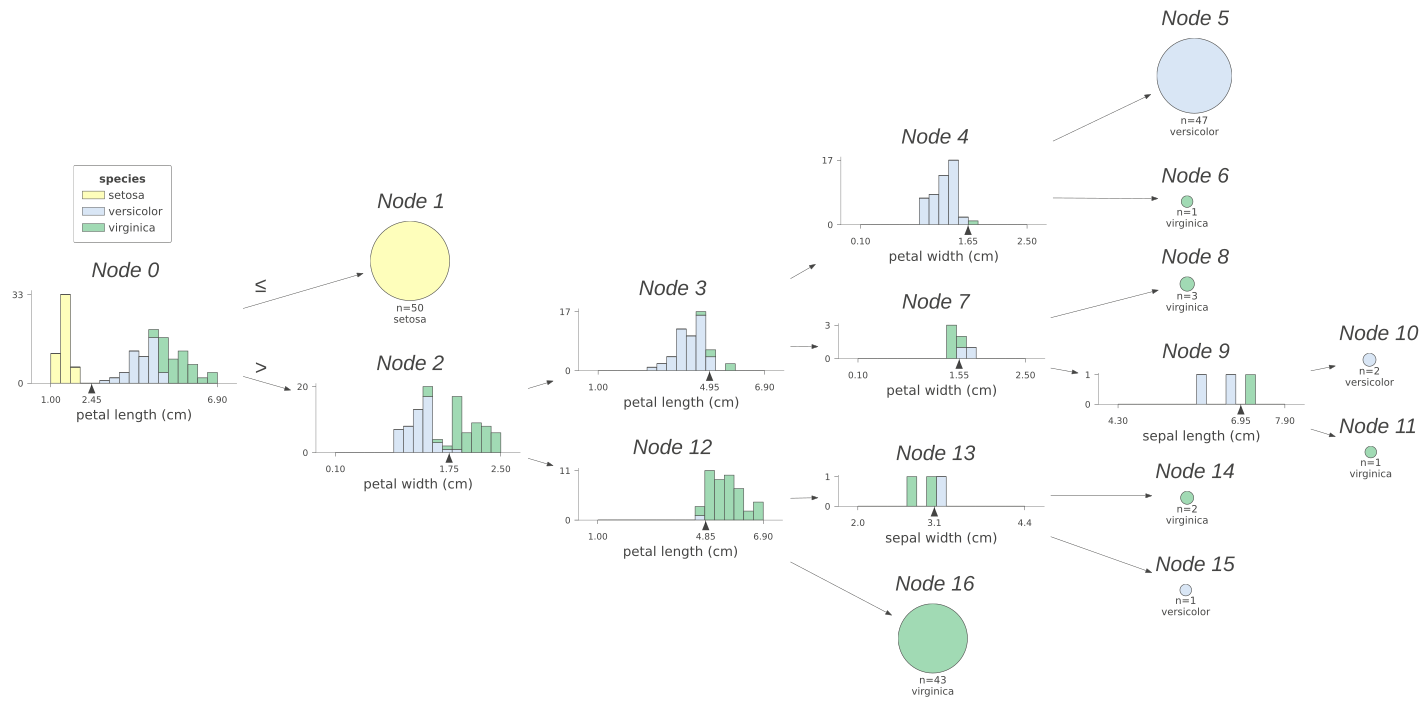

In [ ]:
m = model(clas,
          X_train=X_train,
          y_train=y_train,
          feature_names=iris.feature_names,
          target_name='species', # Corrected for Iris dataset
          class_names=iris.target_names) # Using iris.target_names
viz = m.view(histtype='barstacked',
             scale=1.5,
             orientation='LR',
             show_node_labels=True)
viz

6. Without any graphs

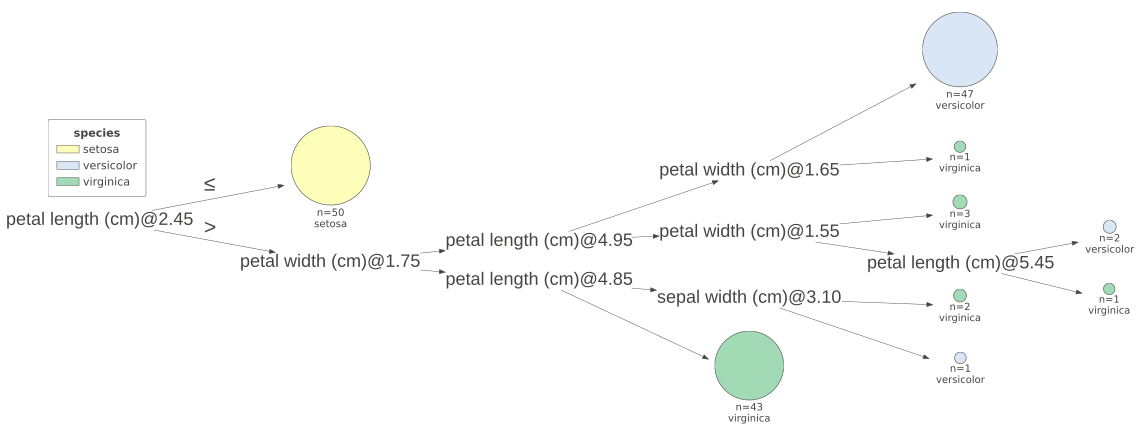

In [ ]:
m = model(clas,
          X_train=X_train,
          y_train=y_train,
          feature_names=iris.feature_names,
          target_name='species', # Corrected for Iris dataset
          class_names=iris.target_names) # Using iris.target_names
viz = m.view(histtype='barstacked',
             scale=1.5,
             orientation='LR',
             fancy=False)
viz

7. Show just prediction path, nothing else

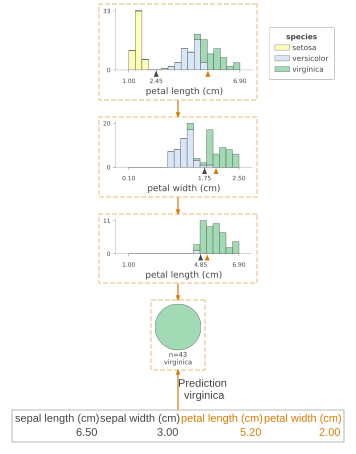

In [ ]:
clas = tree.DecisionTreeClassifier()
iris = load_iris()

X_train = iris.data
y_train = iris.target
clas.fit(X_train, y_train)

X = iris.data[np.random.randint(0, len(iris.data)),:]

m = model(clas,
          X_train=X_train,
          y_train=y_train,
          feature_names=iris.feature_names,
          target_name='species', # Corrected for Iris dataset
          class_names=iris.target_names) # Using iris.target_names
viz = m.view(x=X, # X is passed as 'x' to view()
             show_just_path=True)
viz

8. Prediction Path in Plain english

In [ ]:
from dtreeviz import model

m = model(clas, X_train=X_train, y_train=y_train, feature_names=iris.feature_names, class_names=iris.target_names)
print(m.explain_prediction_path(x=X))

4.85 <= petal length (cm) 
1.75 <= petal width (cm) 



9. Feature Importance

/tmp/ipykernel_935/2146121201.py:1: DeprecationWarning: explain_prediction_path(explanation_type='sklearn_default') function is deprecated starting from version 2.0. 
 For the same functionality, please use this code instead: 
 m = dtreeviz.model(...) 
 m.instance_feature_importance()


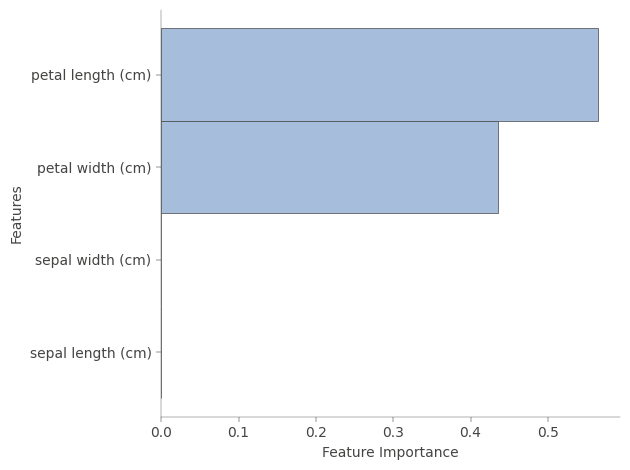

None


In [ ]:
print(explain_prediction_path(clas, X, feature_names=iris.feature_names, explanation_type="sklearn_default"))

10. Univariate Regression

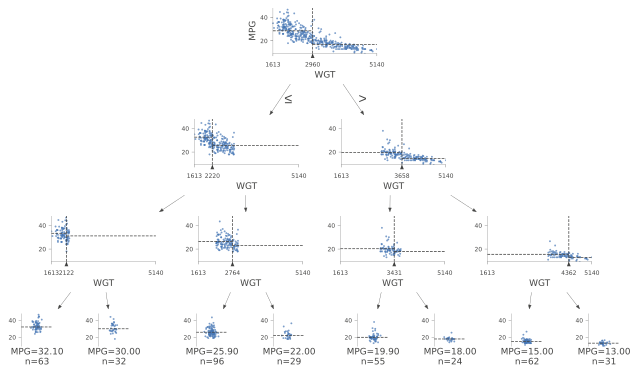

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from dtreeviz import model # Import the 'model' API for modern dtreeviz usage
import os # Import os for path checking

# Check if cars.csv exists, if not, download it
if not os.path.exists("cars.csv"):
    print("cars.csv not found, downloading...")
    # Using a common public URL for cars.csv from dtreeviz examples
    !wget -q https://raw.githubusercontent.com/parrt/dtreeviz/master/data/cars.csv

df_cars = pd.read_csv("cars.csv")
X_df, y = df_cars[['WGT']], df_cars['MPG'] # Keep X_df as DataFrame
X_array = X_df.values # Convert X to a NumPy array

dt = DecisionTreeRegressor(max_depth=3, criterion="absolute_error") # Changed 'mae' to 'absolute_error'
dt.fit(X_array, y) # Fit with the NumPy array

# Use the dtreeviz.model API for visualization
m = model(dt, X_train=X_array, y_train=y,
          feature_names=['WGT'], target_name='MPG')

viz = m.view()
viz

11. 3D Regression

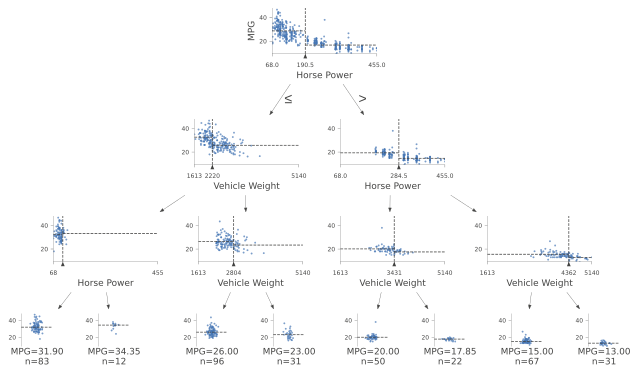

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.tree import DecisionTreeRegressor
from dtreeviz import model # Import the 'model' API
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plt.figure()

X_df = df_cars[['WGT','ENG']] # Keep X_df as DataFrame for context
X = X_df.values # Convert X to a NumPy array for consistency
y = df_cars['MPG']

dt = DecisionTreeRegressor(max_depth=3, criterion="absolute_error") # Changed 'mae' to 'absolute_error'
dt.fit(X, y) # Fit with the NumPy array

# The previous lines creating fig, ax and setting ax.view_init, ax.dist are removed.
# dtreeviz.model().view() is expected to handle figure/axes creation for 3D plots.

# Use the dtreeviz.model API for 3D visualization
m = model(dt, X_train=X, y_train=y,
          feature_names=['Vehicle Weight', 'Horse Power'],
          target_name='MPG')

viz = m.view() # Removed 'ax' parameter
viz

In [ ]:
import seaborn as sns
df =sns.load_dataset('iris')

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder = LabelEncoder()

In [ ]:
df['species'] = encoder.fit_transform(df['species'])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


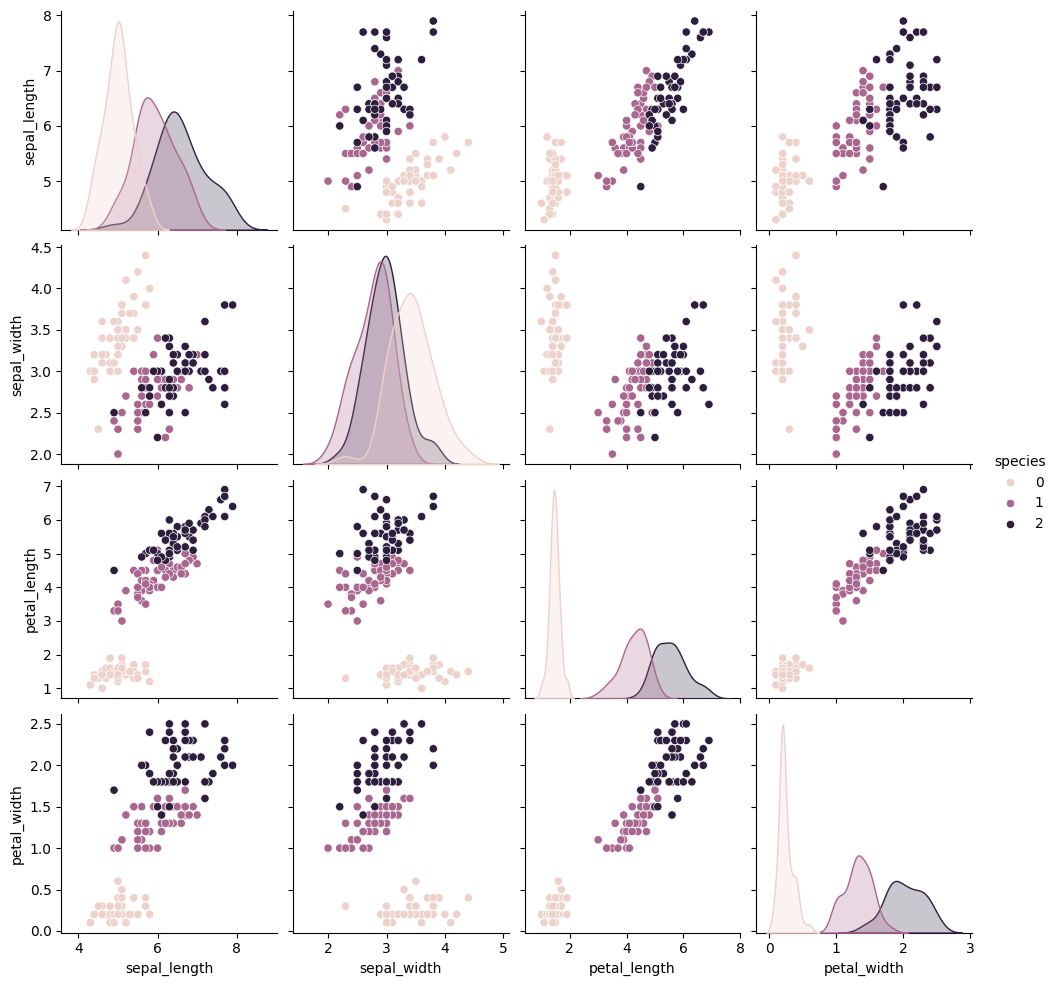

In [ ]:
sns.pairplot(df,hue='species')

In [ ]:
new_df = df[df['species'] != 0][['sepal_length','sepal_width','species']]
new_df.head()

,sepal_length,sepal_width,species
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1


In [ ]:
new_df.shape

(100, 3)

In [ ]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
clf1 = LogisticRegression()
clf2 = RandomForestClassifier()
clf3 = KNeighborsClassifier()

In [ ]:
estimators = [('lr',clf1),('rf',clf2),('knn',clf3)]

In [ ]:
for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10, scoring = 'accuracy')
    print(estimator[0],np.round(np.mean(x),2))

lr 0.81
rf 0.72
knn 0.76


In [ ]:
from sklearn.ensemble import VotingClassifier

Hard Voting

In [ ]:
vc = VotingClassifier(estimators=estimators,voting='hard')
x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.76


Soft Voting

In [ ]:
vc1 = VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc1,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.76


Weighted Voting

In [ ]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            vc = VotingClassifier(estimators=estimators,voting='soft',weights=[i,j,k])
            x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
            print("for i={},j={},k={}".format(i,j,k),np.round(np.mean(x),2))


for i=1,j=1,k=1 0.77
for i=1,j=1,k=2 0.75
for i=1,j=1,k=3 0.75
for i=1,j=2,k=1 0.75
for i=1,j=2,k=2 0.75
for i=1,j=2,k=3 0.76
for i=1,j=3,k=1 0.74
for i=1,j=3,k=2 0.75
for i=1,j=3,k=3 0.75
for i=2,j=1,k=1 0.79
for i=2,j=1,k=2 0.77
for i=2,j=1,k=3 0.77
for i=2,j=2,k=1 0.76
for i=2,j=2,k=2 0.76
for i=2,j=2,k=3 0.76
for i=2,j=3,k=1 0.74
for i=2,j=3,k=2 0.75
for i=2,j=3,k=3 0.75
for i=3,j=1,k=1 0.79
for i=3,j=1,k=2 0.78
for i=3,j=1,k=3 0.79
for i=3,j=2,k=1 0.78
for i=3,j=2,k=2 0.77
for i=3,j=2,k=3 0.77
for i=3,j=3,k=1 0.75
for i=3,j=3,k=2 0.77
for i=3,j=3,k=3 0.75


Classifiers of same Algo

In [ ]:
from sklearn.svm import SVC

In [ ]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=2)

svm1 = SVC(probability=True, kernel='poly', degree=1)
svm2 = SVC(probability=True, kernel='poly', degree=2)
svm3 = SVC(probability=True, kernel='poly', degree=3)
svm4 = SVC(probability=True, kernel='poly', degree=4)
svm5 = SVC(probability=True, kernel='poly', degree=5)

estimators = [('svm1',svm1),('svm2',svm2),('svm3',svm3),('svm4',svm4),('svm5',svm5)]

for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))

svm1 0.85
svm2 0.85
svm3 0.89
svm4 0.81
svm5 0.86


In [ ]:
vc1 = VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc1,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.93


Voting Regressor

In [1]:
from sklearn.datasets import load_diabetes
import numpy as np

In [2]:
X, y = load_diabetes(return_X_y=True)

In [3]:
X.shape

(442, 10)

In [4]:
y.shape

(442,)

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score


In [6]:
lr = LinearRegression()
knn = KNeighborsRegressor()
svr = SVR()

In [7]:
estimators = [('lr',lr),('knn',knn),('svr',svr)]

In [9]:
for estimator in estimators:
  scores = cross_val_score(estimator[1],X,y, scoring = 'r2', cv = 10)
  print(estimator[0], np.round(np.mean(scores),2))

lr 0.46
knn 0.33
svr 0.15


In [10]:
from sklearn.ensemble import VotingRegressor

In [11]:
vr = VotingRegressor(estimators)
scores = cross_val_score(vr,X,y,scoring='r2',cv=10)
print("Voting Regressor",np.round(np.mean(scores),2))

Voting Regressor 0.41


In [12]:
for i in range(1,5):
  for j in range(1,5):
    for k in range(1,5):
      vr = VotingRegressor(estimators,weights=[i,j,k])
      scores = cross_val_score(vr,X,y,scoring='r2',cv=10)
      print("For i={},j={},k={}".format(i,j,k), np.round(np.mean(scores),2))

For i=1,j=1,k=1 0.41
For i=1,j=1,k=2 0.37
For i=1,j=1,k=3 0.34
For i=1,j=1,k=4 0.32
For i=1,j=2,k=1 0.41
For i=1,j=2,k=2 0.38
For i=1,j=2,k=3 0.36
For i=1,j=2,k=4 0.34
For i=1,j=3,k=1 0.4
For i=1,j=3,k=2 0.39
For i=1,j=3,k=3 0.37
For i=1,j=3,k=4 0.35
For i=1,j=4,k=1 0.39
For i=1,j=4,k=2 0.38
For i=1,j=4,k=3 0.37
For i=1,j=4,k=4 0.36
For i=2,j=1,k=1 0.44
For i=2,j=1,k=2 0.41
For i=2,j=1,k=3 0.38
For i=2,j=1,k=4 0.36
For i=2,j=2,k=1 0.43
For i=2,j=2,k=2 0.41
For i=2,j=2,k=3 0.39
For i=2,j=2,k=4 0.37
For i=2,j=3,k=1 0.42
For i=2,j=3,k=2 0.41
For i=2,j=3,k=3 0.4
For i=2,j=3,k=4 0.38
For i=2,j=4,k=1 0.42
For i=2,j=4,k=2 0.41
For i=2,j=4,k=3 0.4
For i=2,j=4,k=4 0.38
For i=3,j=1,k=1 0.45
For i=3,j=1,k=2 0.43
For i=3,j=1,k=3 0.41
For i=3,j=1,k=4 0.39
For i=3,j=2,k=1 0.45
For i=3,j=2,k=2 0.43
For i=3,j=2,k=3 0.41
For i=3,j=2,k=4 0.4
For i=3,j=3,k=1 0.44
For i=3,j=3,k=2 0.43
For i=3,j=3,k=3 0.41
For i=3,j=3,k=4 0.4
For i=3,j=4,k=1 0.43
For i=3,j=4,k=2 0.42
For i=3,j=4,k=3 0.41
For i=3,j=4,k=4 0.

In [15]:
from sklearn.tree import DecisionTreeRegressor

In [16]:
# Using the same algorithm
dt1 = DecisionTreeRegressor(max_depth=1)
dt2 = DecisionTreeRegressor(max_depth=3)
dt3 = DecisionTreeRegressor(max_depth=5)
dt4 = DecisionTreeRegressor(max_depth=7)
dt5 = DecisionTreeRegressor(max_depth=None)


estimators = [('dt1',dt1),('dt2',dt2),('dt3',dt3),('dt4',dt4),('dt5',dt5)]

In [17]:
for estimator in estimators:
  scores = cross_val_score(estimator[1],X,y,scoring='r2',cv=10)
  print(estimator[0],np.round(np.mean(scores),2))

dt1 0.15
dt2 0.28
dt3 0.14
dt4 -0.07
dt5 -0.25


In [18]:
vr = VotingRegressor(estimators)
scores = cross_val_score(vr,X,y,scoring='r2',cv=10)
print("Voting Regressor",np.round(np.mean(scores),2))

Voting Regressor 0.21
